In [6]:
import os, time, copy
from glob import glob
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from torchvision import datasets, transforms

# 한글 폰트 설정 (윈도우)
plt.rcParams["font.family"] = "Malgun Gothic"   # 맑은 고딕
plt.rcParams["axes.unicode_minus"] = False       # 마이너스 깨짐 방지

torch.manual_seed(42)
np.random.seed(42)


if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(torch.__version__)
print(device)

2.11.0+cu128
cuda


In [10]:
train_dir = "./cityscapes/cityscapes/train/"   # 두 번
val_dir = "./cityscapes/cityscapes/val/"

if not os.path.isdir(train_dir):
    print("No folder")
else:
    train_lists = sorted(glob(f"{train_dir}*.jpg"))
    val_lists = sorted(glob(f"{val_dir}*.jpg"))
    print(f"train {len(train_lists)}장, val {len(val_lists)}장")

train 2975장, val 500장


In [12]:
from collections import namedtuple

Label=namedtuple('Lavel', ['name', 'id', 'trainId','category','categoryId','hasInstances','ignoreInEval','color'])

labels = [
    Label('unlabeled',            0, 255, 'void',         0, False, True,  (0,0,0)),
    Label('egovehicle',           1, 255, 'void',         0, False, True,  (0,0,0)),
    Label('rectificationborder',  2, 255, 'void',         0, False, True,  (0,0,0)),
    Label('outofroi',             3, 255, 'void',         0, False, True,  (0,0,0)),
    Label('static',               4, 255, 'void',         0, False, True,  (0,0,0)),
    Label('dynamic',              5, 255, 'void',         0, False, True,  (111,74,0)),
    Label('ground',               6, 255, 'void',         0, False, True,  (81,0,81)),
    Label('road',                 7,   0, 'ground',       1, False, False, (128,64,128)),
    Label('sidewalk',             8,   1, 'ground',       1, False, False, (244,35,232)),
    Label('parking',              9, 255, 'ground',       1, False, True,  (250,170,160)),
    Label('railtrack',           10, 255, 'ground',       1, False, True,  (230,150,140)),
    Label('building',            11,   2, 'construction', 2, False, False, (70,70,70)),
    Label('wall',                12,   3, 'construction', 2, False, False, (102,102,156)),
    Label('fence',               13,   4, 'construction', 2, False, False, (190,153,153)),
    Label('guardrail',           14, 255, 'construction', 2, False, True,  (180,165,180)),
    Label('bridge',              15, 255, 'construction', 2, False, True,  (150,100,100)),
    Label('tunnel',              16, 255, 'construction', 2, False, True,  (150,120,90)),
    Label('pole',                17,   5, 'object',       3, False, False, (153,153,153)),
    Label('polegroup',           18, 255, 'object',       3, False, True,  (153,153,153)),
    Label('trafficlight',        19,   6, 'object',       3, False, False, (250,170,30)),
    Label('trafficsign',         20,   7, 'object',       3, False, False, (220,220,0)),
    Label('vegetation',          21,   8, 'nature',       4, False, False, (107,142,35)),
    Label('terrain',             22,   9, 'nature',       4, False, False, (152,251,152)),
    Label('sky',                 23,  10, 'sky',          5, False, False, (70,130,180)),
    Label('person',              24,  11, 'human',        6, True,  False, (220,20,60)),
    Label('rider',               25,  12, 'human',        6, True,  False, (255,0,0)),
    Label('car',                 26,  13, 'vehicle',      7, True,  False, (0,0,142)),
    Label('truck',               27,  14, 'vehicle',      7, True,  False, (0,0,70)),
    Label('bus',                 28,  15, 'vehicle',      7, True,  False, (0,60,100)),
    Label('caravan',             29, 255, 'vehicle',      7, True,  True,  (0,0,90)),
    Label('trailer',             30, 255, 'vehicle',      7, True,  True,  (0,0,110)),
    Label('train',               31,  16, 'vehicle',      7, True,  False, (0,80,100)),
    Label('motorcycle',          32,  17, 'vehicle',      7, True,  False, (0,0,230)),
    Label('bicycle',             33,  18, 'vehicle',      7, True,  False, (119,11,32)),
    Label('licenseplate',        34,  19, 'vehicle',      7, False, True,  (0,0,142)),
]

N_CLASSES = len(labels)
IMAGE_SIZE = 128
BATCH_SIZE = 16

id2color_arr = np.array([l.color for l in labels], dtype = np.uint8)
print(f"클래스 {N_CLASSES}개, 색상표 {id2color_arr.shape}")

클래스 35개, 색상표 (35, 3)


In [13]:
def image_mask_split(filename, image_size):
    image_mask = Image.open(filename)
    image = image_mask.crop([0, 0, 256, 256])
    mask = image_mask.crop([256, 0, 512, 256])
    image = image.resize((image_size, image_size))
    mask = mask.resize((image_size, image_size), Image.NEAREST)
    return np.array(image), np.array(mask)

def encode_mask(mask, colors = id2color_arr):
    diff = mask[:, :, None, :].astype(np.int16) - colors[None, None, :, :].astype(np.int16)
    dist = np.linalg.norm(diff, axis = -1)
    return np.argmin(dist, axis = -1).astype(np.uint8)

def decode_mask(enc, colors = id2color_arr):
    return colors[enc]

In [15]:
def build_dataset(file_list, desc):
    images, masks_enc = [], []
    for f in tqdm(file_list, desc = desc):
        img, mask = image_mask_split(f, IMAGE_SIZE)
        images.append(img)
        masks_enc.append(encode_mask(mask))
    return np.stack(images), np.stack(masks_enc)

if os.path.isdir(train_dir):
    t0 = time.time()
    train_images, train_masks_enc = build_dataset(train_lists,"Tranin Dataset")
    val_images, val_masks_enc = build_dataset(val_lists, "Validation Dataset")
    print(t0- time.time())
    print(train_images.shape, train_images.dtype)
    print(train_masks_enc.shape, train_masks_enc.dtype)
    print(train_masks_enc.min(), train_masks_enc.max())

Tranin Dataset:   0%|          | 0/2975 [00:00<?, ?it/s]

Validation Dataset:   0%|          | 0/500 [00:00<?, ?it/s]

-88.70355367660522
(2975, 128, 128, 3) uint8
(2975, 128, 128) uint8
0 33


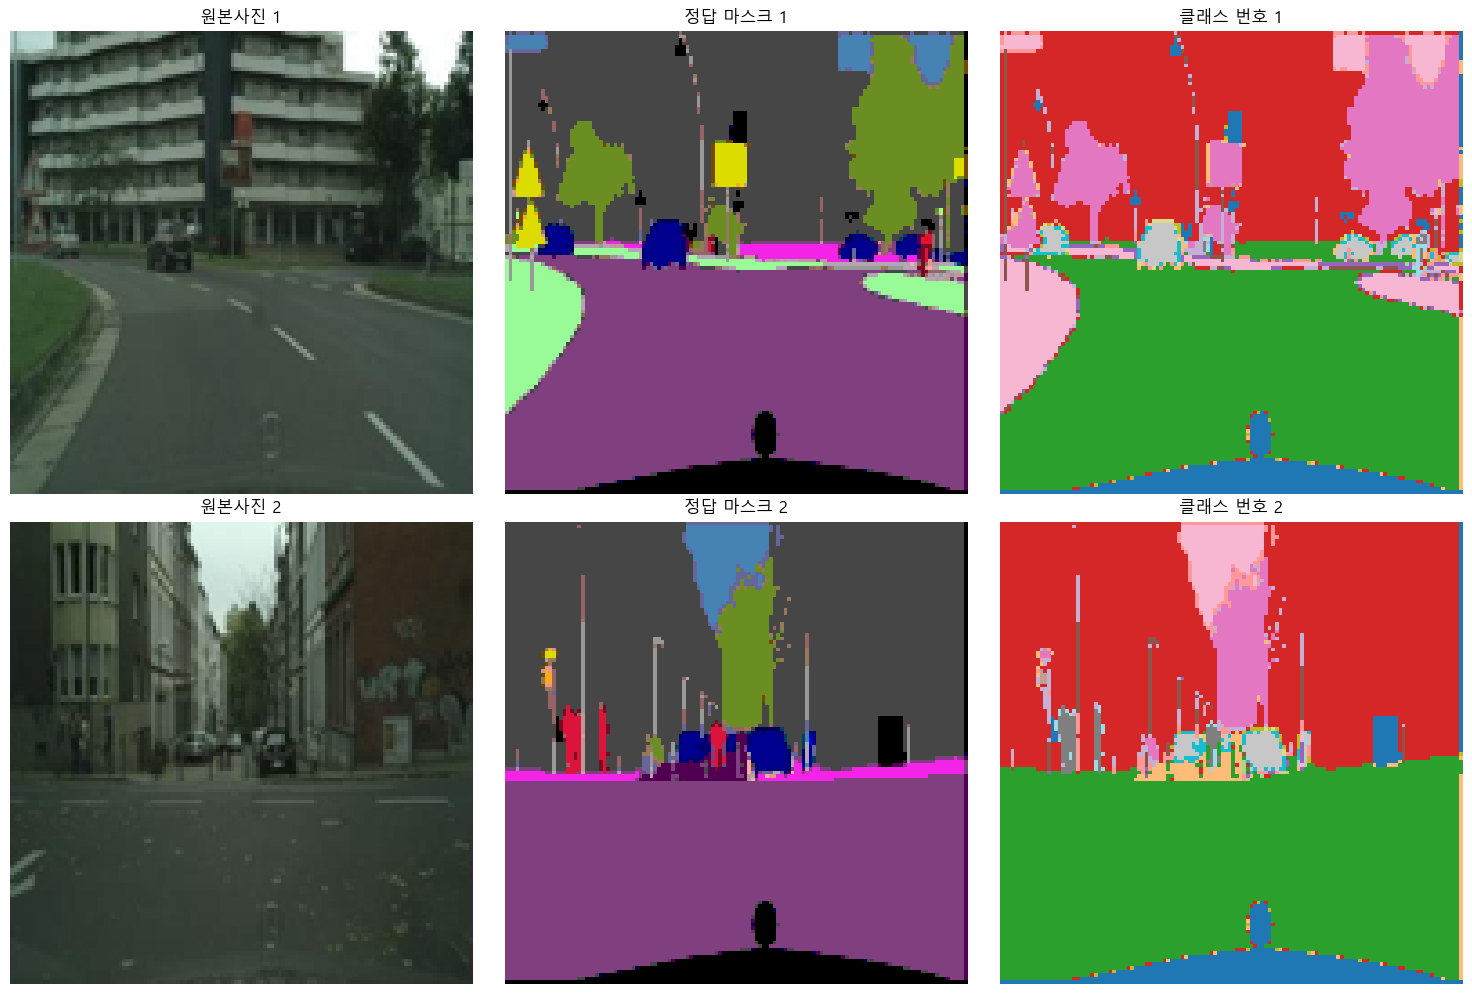

In [17]:
# 눈으로 확인하기(데이터셋 나누고 난 후에)

plt.figure(figsize=(15,10))
for i in range(2):
    for j, (arr, title) in enumerate([
        (train_images[i], f"원본사진 {i+1}"),
        (decode_mask(train_masks_enc[i]), f"정답 마스크 {i+1}"),
        (train_masks_enc[i], f"클래스 번호 {i+1}")
    ]):
        # 이 아래를 for 안으로 (8칸 들여쓰기)
        plt.subplot(2, 3, i*3 + j + 1)
        plt.imshow(arr, cmap="tab20" if j == 2 else None)
        plt.axis("off")
        plt.title(title)

plt.tight_layout()
plt.show()

In [19]:
class SegDataset(Dataset):
    def __init__(self, images, masks):
        self.images = images
        self.masks = masks

    def __len__(self):
        return len(self.images)

    def __getitem__(self, i):
        img = self.images[i].astype(np.float32) / 255.0
        img = np.transpose(img, (2, 0, 1))
        mask = torch.from_numpy(self.masks[i].astype(np.int64))
        return torch.from_numpy(img), mask

if os.path.isdir(train_dir):
    train_loader = DataLoader(SegDataset(train_images, train_masks_enc), batch_size = BATCH_SIZE, shuffle = True)
    val_loader = DataLoader(SegDataset(val_images, val_masks_enc),batch_size = BATCH_SIZE, shuffle = False)

    xb, yb = next(iter(train_loader))
    print(tuple(xb.shape), xb.dtype)
    print(tuple(yb.shape), yb.dtype)

(16, 3, 128, 128) torch.float32
(16, 128, 128) torch.int64


In [24]:
def conv2d_block(in_ch, out_ch, kernel_size = 3):
    layers = []
    for i in range(2):
        layers += [
            nn.Conv2d(in_ch if i == 0 else out_ch, out_ch, kernel_size, padding = kernel_size // 2),
            nn.ReLU(inplace = True)
        ]
    return nn.Sequential(*layers)

class EncoderBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout = 0.3):
        super().__init__()
        self.conv = conv2d_block(in_ch, out_ch)
        self.pool = nn.MaxPool2d(2)
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        f = self.conv(x)
        p = self.drop(self.pool(f))
        return f, p

class DecoderBlock(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch, dropout = 0.3):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_ch, out_ch, 3, stride = 2, padding = 1, output_padding = 1)
        self.drop = nn.Dropout(dropout)
        self.conv = conv2d_block(out_ch + skip_ch, out_ch)

    def forward(self, x, skip):
        u = self.up(x)
        c = torch.cat([u, skip], dim = 1)
        return self.conv(self.drop(c))

class UNet(nn.Module):
    def __init__(self, n_classes = N_CLASSES, in_ch = 3):
        super().__init__()
        self.enc1 = EncoderBlock(in_ch, 64)
        self.enc2 = EncoderBlock(64, 128)
        self.enc3 = EncoderBlock(128, 256)
        self.enc4 = EncoderBlock(256, 512)

        self.bottleneck = conv2d_block(512, 1024)

        self.dec1 = DecoderBlock(1024, 512, 512)
        self.dec2 = DecoderBlock(512, 256, 256)
        self.dec3 = DecoderBlock(256, 128, 128)
        self.dec4 = DecoderBlock(128, 64, 64)

        self.out = nn.Conv2d(64, n_classes, 1)
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d)):
                nn.init.kaiming_normal_(m.weight, nonlinearity = "relu")
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
    
    def forward(self, x):
        f1, p1 = self.enc1(x)
        f2, p2 = self.enc2(p1)
        f3, p3 = self.enc3(p2)
        f4, p4 = self.enc4(p3)
        b = self.bottleneck(p4)
        c = self.dec1(b, f4)
        c = self.dec2(c, f3)
        c = self.dec3(c, f2)
        c = self.dec4(c, f1)
        return self.out(c)

model = UNet()
with torch.no_grad():
    out = model(torch.zeros(1, 3, IMAGE_SIZE, IMAGE_SIZE))
print(tuple(out.shape))
print(sum(p.numel() for p in model.parameters()))


(1, 35, 128, 128)
34515555


In [29]:
@torch.no_grad()
def evaluate_seg(model, loader, criterion):
    model.eval()
    tot_loss, tot_correct, tot_pixels = 0.0, 0, 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)
        loss = criterion(logits, yb)
        tot_loss += loss.item() * xb.size(0)
        preds = logits.argmax(dim = 1)
        tot_correct += (preds == yb).sum().item()
        tot_pixels += yb.numel()
    n = len(loader.dataset)
    return tot_loss / n, tot_correct / tot_pixels

def train_unet(model, train_loader, val_loader, epochs = 2, lr = 1e-3, ckpt_path = "cityscapes-unit.pt"):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr = lr)

    history = {'loss':[], 'val_loss':[], 'accuracy':[], 'val_acc':[]}
    best_val = float('inf')

    for epoch in range(1, epochs +1):
        model.train()
        run_loss, run_correct, run_px = 0.0, 0, 0
        t0 = time.time()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

            run_loss += loss.item() * xb.size(0)
            run_correct += (logits.argmax(1) == yb).sum().item()
            run_px += yb.numel()
        tr_loss = run_loss / len(train_loader.dataset)
        tr_acc = run_correct / run_px
        val_loss, val_acc = evaluate_seg(model, val_loader, criterion)

        history["loss"].append(tr_loss)
        history["accuracy"].append(tr_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        star = ""
        if val_loss < best_val:
            best_val = val_loss
            torch.save(model.state_dict(), ckpt_path)
            star = '저장'
        print(f"{epoch}/{epochs} loss {tr_loss} acc{tr_acc}")
        print(f"val_loss {val_loss} val_acc {val_acc}")
    print(f'최저 {best_val} : {ckpt_path}')
    return history



In [30]:
EPOCHS = 2

model = UNet()
history = train_unet(model, train_loader, val_loader, epochs = EPOCHS, lr = 1e-3)

1/2 loss 1.69425954406001 acc0.5525949686515231
val_loss 1.1867618236541748 val_acc 0.6726622314453125
2/2 loss 1.0444779292475275 acc0.7179743303571429
val_loss 0.9907650318145752 val_acc 0.7361180419921876
최저 0.9907650318145752 : cityscapes-unit.pt


In [36]:
@torch.no_grad()
def compute_miou(model, loader, n_classes = N_CLASSES):
    model.eval()
    inter = torch.zeros(n_classes)
    union = torch.zeros(n_classes)

    for xb, yb in loader:
        pred = model(xb.to(device)).argmax(1).cpu()
        for c in range(n_classes):
            p, t = (pred == c), (yb == c)
            inter[c] += (p & t).sum()
            union[c] += (p | t).sum()

    present = (union > 0).nonzero().squeeze(1)
    iou = inter[present] / union[present]
    return iou.mean().item(), present.numpy(), iou.numpy()

miou, present_ids, iou_vals = compute_miou(model, val_loader)
_, pixel_acc = evaluate_seg(model, val_loader, nn.CrossEntropyLoss())

print(pixel_acc)
print(miou)
print(len(present_ids))

names = [l.name for l in labels]
order = np.argsort(-iou_vals)

print("잘 맞힌거")
for k in order[:5]:
    print(names[present_ids[k]], iou_vals[k])

print("잘 못맞힌거")
for k in order[-5:]:
    print(names[present_ids[k]], iou_vals[k])

0.7361180419921876
0.15503332018852234
29
잘 맞힌거
road 0.7808
sky 0.75601304
vegetation 0.6767753
unlabeled 0.6680442
building 0.5982111
잘 못맞힌거
railtrack 0.0
parking 0.0
dynamic 0.0
trafficsign 0.0
bicycle 0.0


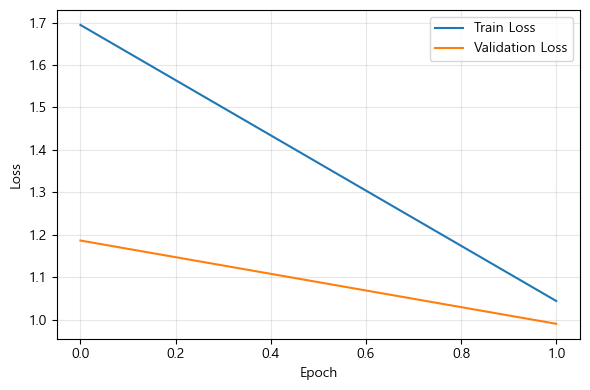

In [37]:
plt.figure(figsize = (6,4))
plt.plot(history['loss'], label = ['Train Loss'])
plt.plot(history['val_loss'], label = ['Validation Loss'])
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc = "upper right")
plt.grid(alpha = 0.3)
plt.tight_layout()
plt.show()

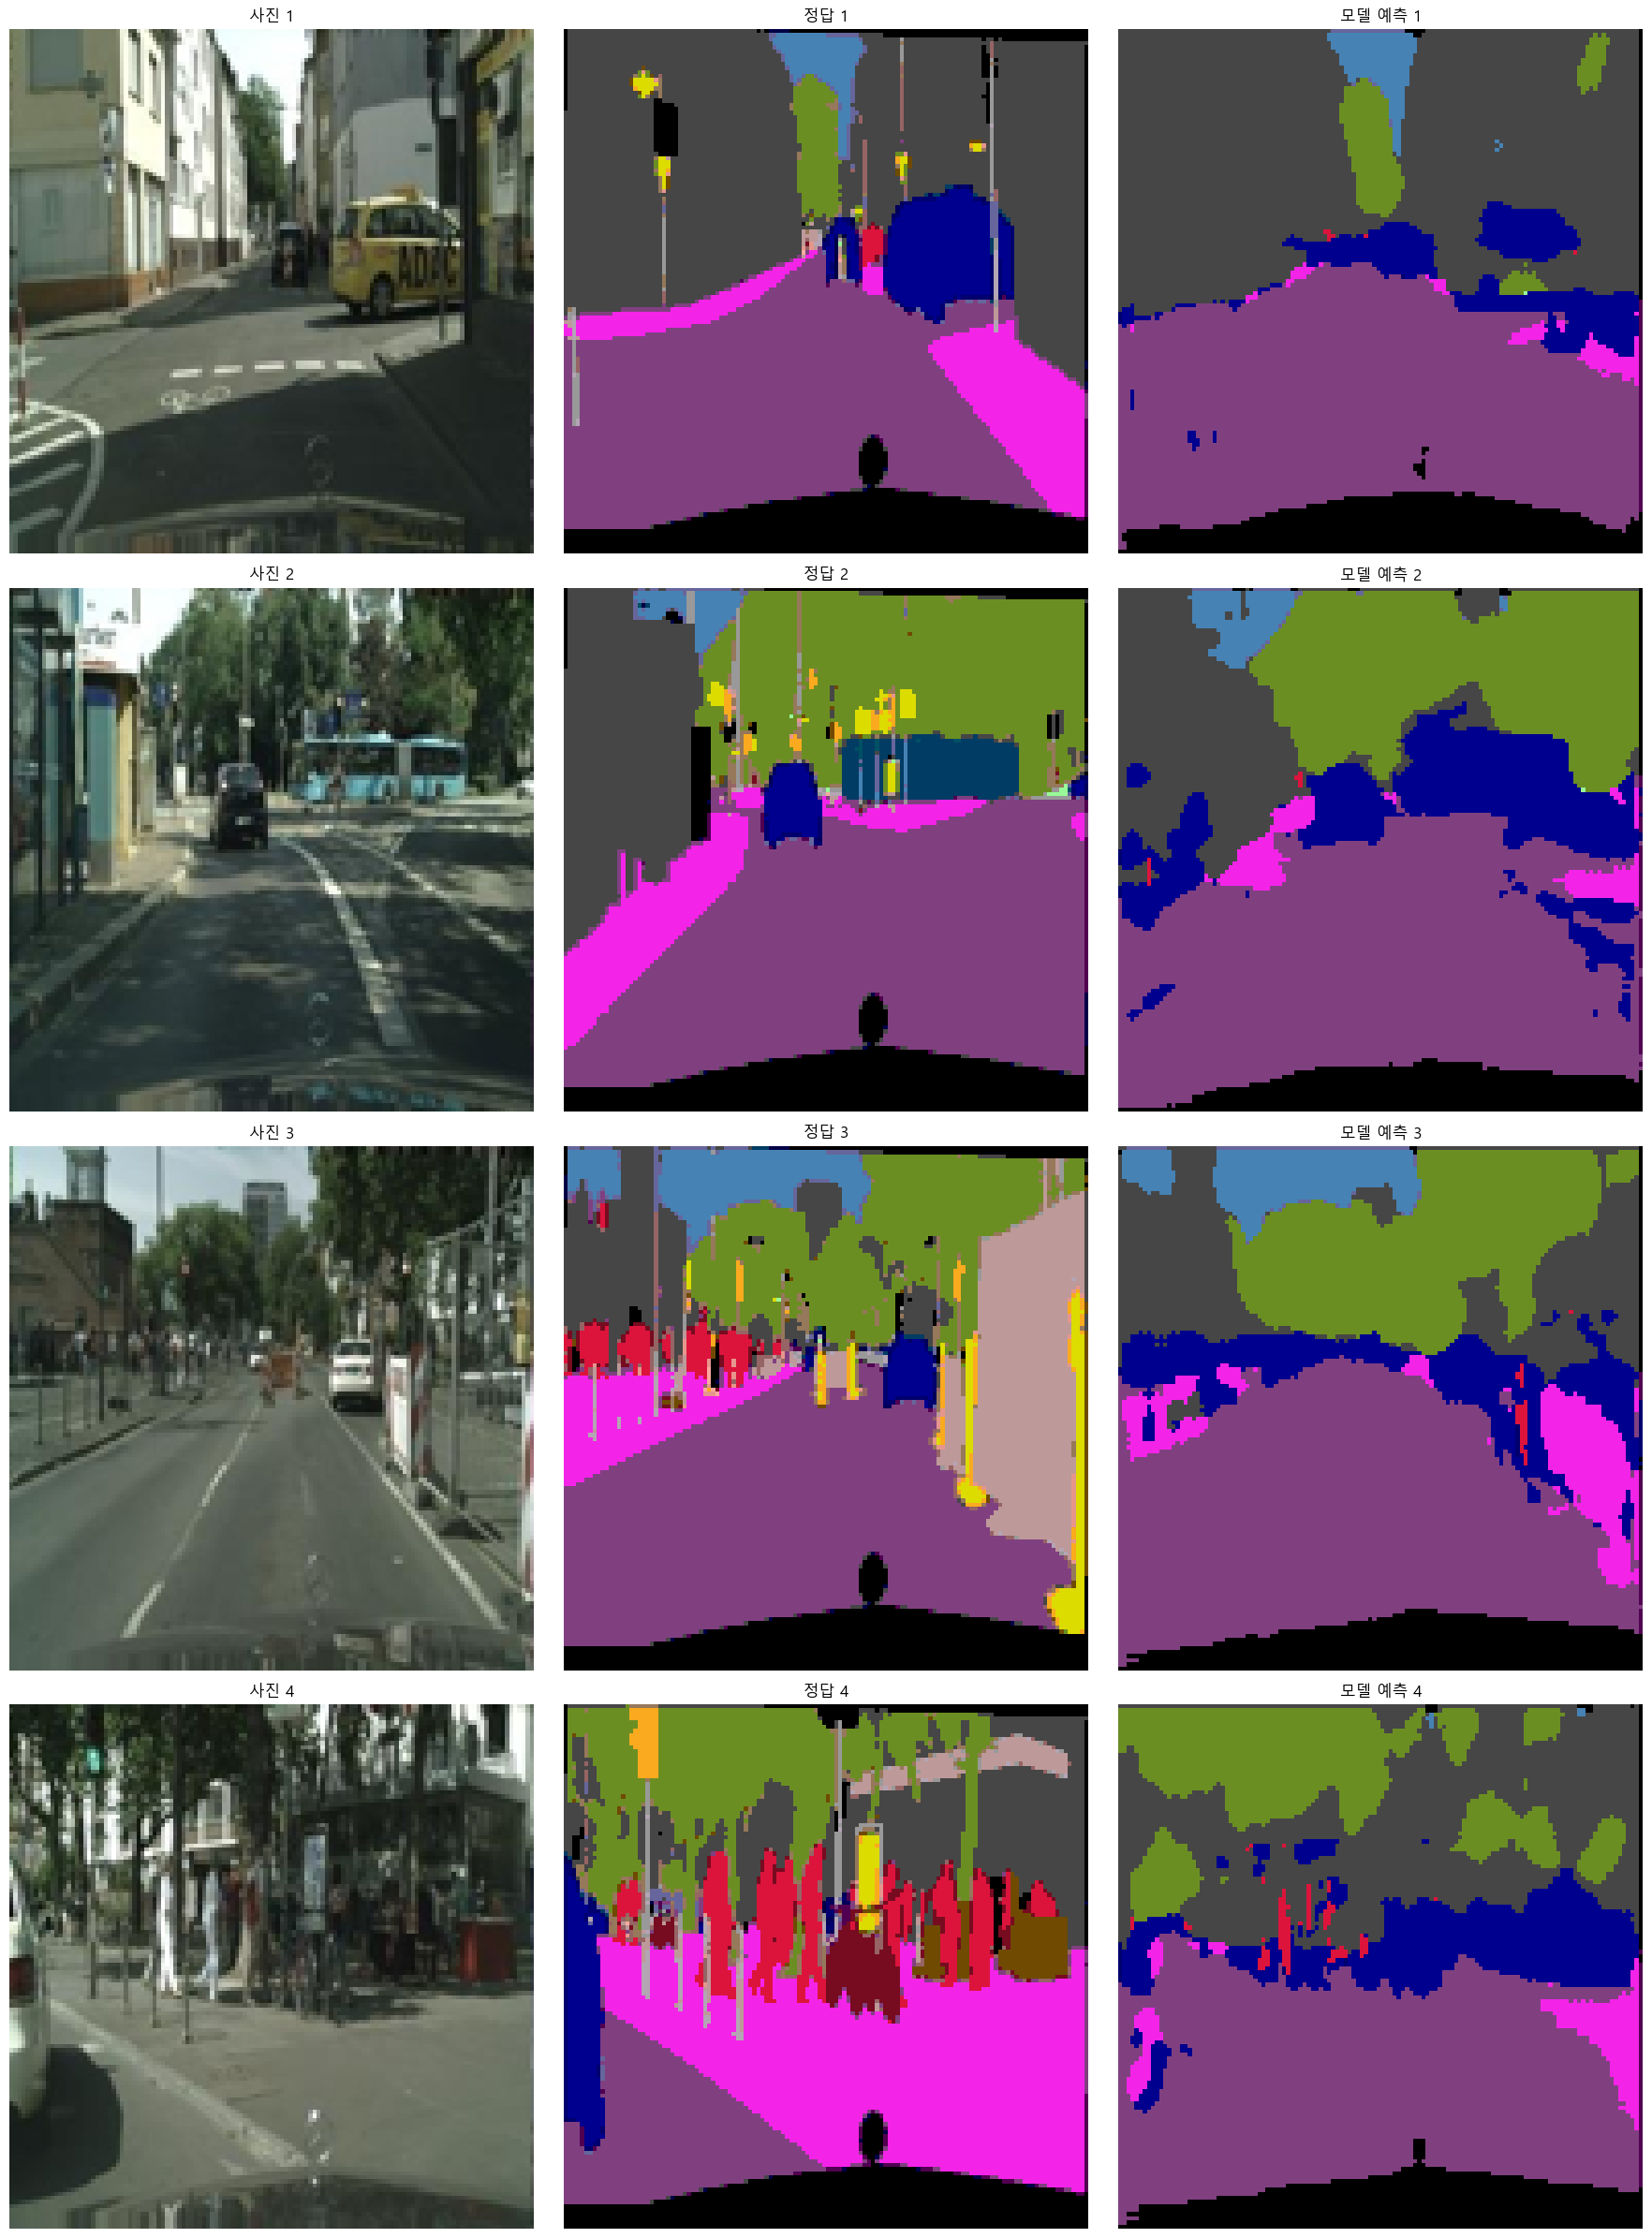

In [42]:
model.load_state_dict(torch.load('cityscapes-unit.pt', map_location = device))
plt.figure(figsize = [18,24])
for i in range(4):
    img_u8 = val_images[i]
    enc = val_masks_enc[i]

    x = torch.from_numpy(
        np.transpose(img_u8.astype(np.float32) / 255.0, (2, 0, 1))
    ).unsqueeze(0).to(device)

    with torch.no_grad():
        pred = model(x).argmax(dim = 1)[0].cpu().numpy()

    for j, (arr, title) in enumerate([
        (img_u8, f'사진 {i + 1}'),
        (decode_mask(enc), f'정답 {i + 1}'),
        (decode_mask(pred),f'모델 예측 {i + 1}')
    ]):
        plt.subplot(4, 3, i*3+j+1)
        plt.imshow(arr)
        plt.axis('off')
        plt.title(title)
plt.tight_layout()
plt.show()